In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Replace with your file path
df = pd.read_excel("../data/Docker_Images_Features.xlsx")  

# Check first few rows
print(df.head())

   Unnamed: 0          Docker Name     Tag Last Update    Size  \
0           4       adminer:latest  latest      9 days   250MB   
1           5  adoptopenjdk:latest  latest   22 months   472MB   
2           9     almalinux:latest  latest     2 weeks   184MB   
3          11          alpine:3.16    3.16     7 weeks  5.54MB   
4          13        alpine:latest    3.16     7 weeks  5.54MB   

  Package Manager     Base Image  # alternative base imgs  \
0             deb    debian:11.7                       12   
1             deb   ubuntu:20.04                        0   
2             rpm            NaN                        0   
3             apk  alpine:3.16.6                        0   
4             apk  alpine:3.18.2                        0   

   number of tested dependencies  number of vulnerabilities  \
0                            152                         66   
1                            132                        131   
2                            150               

In [3]:
# Summary of missing values
print(df.isnull().sum())

Unnamed: 0                         0
Docker Name                        0
Tag                                0
Last Update                        0
Size                               0
Package Manager                    0
Base Image                       333
# alternative base imgs            0
number of tested dependencies      0
number of vulnerabilities          0
Critical Severity                  0
High Severity                      0
Medium Severity                    0
Low Severity                       0
layers                             3
secure                             0
dtype: int64


In [4]:
# Optional: Fill missing values or drop rows
df['Base Image'] = df['Base Image'].fillna('unknown')

In [5]:
df['layers'] = df['layers'].fillna(df['layers'].median())

In [6]:
print(df.isnull().sum())

Unnamed: 0                       0
Docker Name                      0
Tag                              0
Last Update                      0
Size                             0
Package Manager                  0
Base Image                       0
# alternative base imgs          0
number of tested dependencies    0
number of vulnerabilities        0
Critical Severity                0
High Severity                    0
Medium Severity                  0
Low Severity                     0
layers                           0
secure                           0
dtype: int64


In [7]:
drop_cols_reg = ['Docker Name', 'Tag', 'Last Update', 'number of vulnerabilities',
                 'Critical Severity', 'High Severity', 'Medium Severity', 'Low Severity']

df_reg = df.drop(columns=drop_cols_reg)

In [8]:
def size_to_mb(size_str):
    if pd.isnull(size_str):
        return 0
    size_str = size_str.strip()
    if 'MB' in size_str:
        return float(size_str.replace('MB',''))
    elif 'GB' in size_str:
        return float(size_str.replace('GB','')) * 1024
    else:
        # Unknown unit, assume 0
        return 0

df_reg['Size'] = df_reg['Size'].apply(size_to_mb)

In [9]:
# Features
X_reg = df_reg[['Size', 'Package Manager', 'Base Image', '# alternative base imgs',
                'number of tested dependencies', 'layers']] .copy()

# Target
y_reg = df['number of vulnerabilities']


In [10]:
import os
import joblib
from sklearn.preprocessing import LabelEncoder

# Step 1: Initialize
le_package = LabelEncoder()
le_base = LabelEncoder()

# Step 2: Fit on entire dataset (df)
le_package.fit(df['Package Manager'].astype(str))
le_base.fit(df['Base Image'].astype(str))

# Step 3: Transform your training features
X_reg['Package Manager'] = le_package.transform(X_reg['Package Manager'].astype(str))
X_reg['Base Image'] = le_base.transform(X_reg['Base Image'].astype(str))

# Step 4: Save encoders for later use in preprocess.py / API
os.makedirs("../src/model_store", exist_ok=True)
joblib.dump(le_package, "../src/model_store/le_package.pkl")
joblib.dump(le_base, "../src/model_store/le_base.pkl")


['../src/model_store/le_base.pkl']

In [11]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Check shapes of features
print("Training Regressor features:", X_train_reg.shape)
print("Testing Regressor features:", X_test_reg.shape)
# Check shapes of target
print("Training Regressor target:", y_train_reg.shape)
print("Testing Regressor target:", y_test_reg.shape)

Training Regressor features: (622, 6)
Testing Regressor features: (156, 6)
Training Regressor target: (622,)
Testing Regressor target: (156,)


#### Classification

In [12]:
# Drop irrelevant columns
drop_cols_clf = ['Docker Name', 'Tag', 'Last Update', 'number of vulnerabilities']
df_clf = df.drop(columns=drop_cols_clf)

In [13]:
# Features
X_clf = df_clf[['Size', 'Package Manager', 'Base Image', '# alternative base imgs',
                'number of tested dependencies', 'Critical Severity', 'High Severity',
                'Medium Severity', 'Low Severity', 'layers']].copy()

In [14]:
# Convert Size to numeric MB
def size_to_mb(size_str):
    if pd.isna(size_str):
        return 0
    size_str = str(size_str).strip().upper()
    try:
        if 'MB' in size_str:
            return float(size_str.replace('MB','').strip())
        elif 'GB' in size_str:
            return float(size_str.replace('GB','').strip()) * 1024
        elif 'KB' in size_str:
            return float(size_str.replace('KB','').strip()) / 1024
        else:
            return float(size_str)
    except:
        return 0

X_clf['Size'] = X_clf['Size'].apply(size_to_mb).astype(float)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nStatistical Summary of Features:")
print(X_clf.describe())


Statistical Summary of Features:
              Size  # alternative base imgs  number of tested dependencies  \
count   778.000000               778.000000                     778.000000   
mean    315.196490                 5.372751                     127.399743   
std     447.092266                 7.151055                     123.019595   
min       0.001816                 0.000000                       0.000000   
25%      72.800000                 0.000000                      41.000000   
50%     184.500000                 0.000000                     102.000000   
75%     381.000000                 8.000000                     156.750000   
max    3901.440000                28.000000                     849.000000   

       Critical Severity  High Severity  Medium Severity  Low Severity  \
count         778.000000     778.000000       778.000000    778.000000   
mean            4.407455      16.104113        41.271208     65.336761   
std            14.247122      43.829501  

In [16]:
print("\nChecking for abnormal values:")

columns_to_check = ['Size', '# alternative base imgs',
                    'number of tested dependencies', 'layers']

for col in columns_to_check:
    print(f"\nRows where {col} <= 0:")
    print(X_clf[X_clf[col] <= 0])


Checking for abnormal values:

Rows where Size <= 0:
Empty DataFrame
Columns: [Size, Package Manager, Base Image, # alternative base imgs, number of tested dependencies, Critical Severity, High Severity, Medium Severity, Low Severity, layers]
Index: []

Rows where # alternative base imgs <= 0:
       Size Package Manager     Base Image  # alternative base imgs  \
1    472.00             deb   ubuntu:20.04                        0   
2    184.00             rpm        unknown                        0   
3      5.54             apk  alpine:3.16.6                        0   
4      5.54             apk  alpine:3.18.2                        0   
5    114.00             rpm        unknown                        0   
..      ...             ...            ...                      ...   
773    6.91           linux        unknown                        0   
774    5.54             apk  alpine:3.18.3                        0   
775   94.20             apk        unknown                       

In [17]:
import joblib
import os
from sklearn.preprocessing import LabelEncoder

le_package = LabelEncoder()
le_base = LabelEncoder()

le_package.fit(df['Package Manager'].astype(str))
le_base.fit(df['Base Image'].astype(str))

# Step 3: Transform your training features
X_clf['Package Manager'] = le_package.transform(X_clf['Package Manager'].astype(str))
X_clf['Base Image'] = le_base.transform(X_clf['Base Image'].astype(str))

os.makedirs("../src/model_store", exist_ok=True)

joblib.dump(le_package, "../src/model_store/le_package.pkl")
joblib.dump(le_base, "../src/model_store/le_base.pkl")

# Target
y_clf = df['secure']

In [18]:
from sklearn.model_selection import train_test_split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Check shapes of features
print("Training classifier features:", X_train_clf.shape)
print("Testing classifier features:", X_test_clf.shape)
# Check shapes of target
print("Training classifier target:", y_train_clf.shape)
print("Testing classifier target:", y_test_clf.shape)

Training classifier features: (622, 10)
Testing classifier features: (156, 10)
Training classifier target: (622,)
Testing classifier target: (156,)


In [19]:
import os

# Step 1: Create folders if they don't exist
regression_folder = '../data/preprocessed/regression'
classification_folder = '../data/preprocessed/classification'

os.makedirs(regression_folder, exist_ok=True)
os.makedirs(classification_folder, exist_ok=True)

# Step 2: Save regression datasets
X_train_reg.to_csv(f'{regression_folder}/X_train_reg.csv', index=False)
X_test_reg.to_csv(f'{regression_folder}/X_test_reg.csv', index=False)
y_train_reg.to_csv(f'{regression_folder}/y_train_reg.csv', index=False)
y_test_reg.to_csv(f'{regression_folder}/y_test_reg.csv', index=False)

# Step 3: Save classification datasets
X_train_clf.to_csv(f'{classification_folder}/X_train_clf.csv', index=False)
X_test_clf.to_csv(f'{classification_folder}/X_test_clf.csv', index=False)
y_train_clf.to_csv(f'{classification_folder}/y_train_clf.csv', index=False)
y_test_clf.to_csv(f'{classification_folder}/y_test_clf.csv', index=False)

print("All preprocessed datasets saved successfully!")

All preprocessed datasets saved successfully!


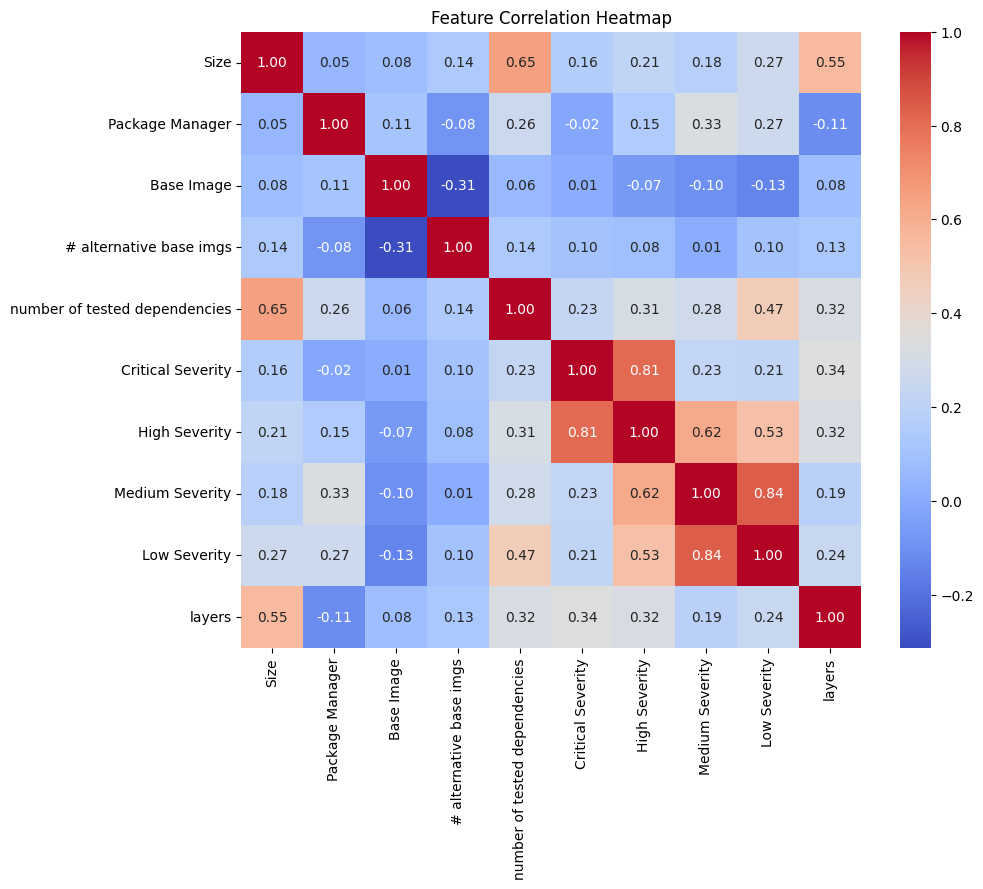

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(X_clf.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

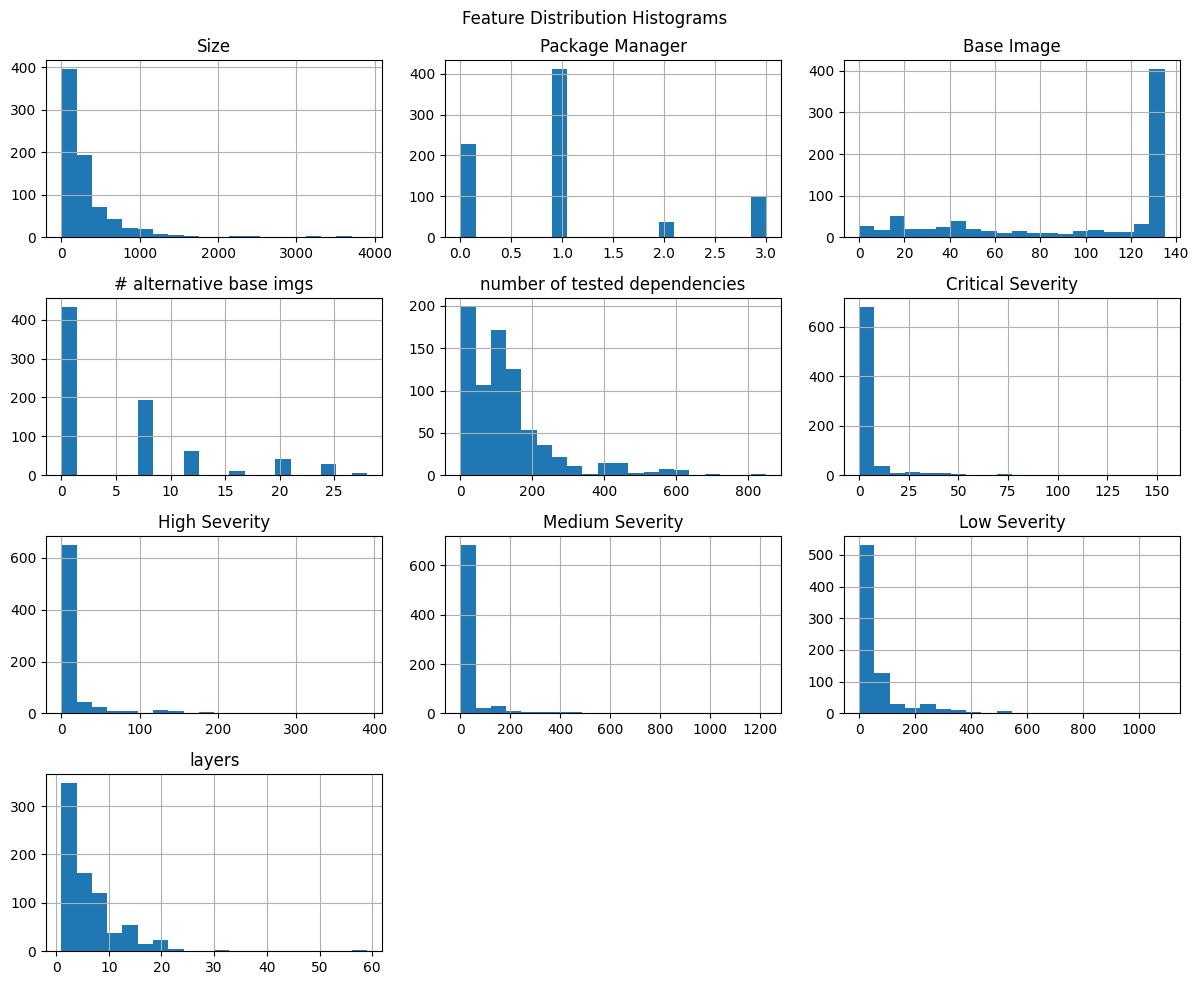

In [21]:
numeric_cols = X_clf.select_dtypes(include=['int64','float64']).columns

X_clf[numeric_cols].hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distribution Histograms")
plt.tight_layout()
plt.show()